# Phase 2: Hybrid Data Pipeline (7-Channel Wavelet Generator)

This notebook builds the engine that transforms your **3-channel RGB images** into **7-channel Hybrid tensors**.

### The 7 Channels:
1. **R**: Red Channel
2. **G**: Green Channel
3. **B**: Blue Channel
4. **LH**: Horizontal Details (High Frequency)
5. **HL**: Vertical Details (High Frequency)
6. **HH**: Diagonal Details (High Frequency)
7. **HF_Reconstructed**: Combined High-Frequency Artifact Map

Traditional deepfake detection models struggle with high-quality GAN outputs. This pipeline extracts **aliasing artifacts** in the frequency domain that are invisible to the naked eye.

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pywt
import matplotlib.pyplot as plt

DATA_DIR = "data"
POOL_A = os.path.join(DATA_DIR, "pool_A")
BATCH_SIZE = 16
IMG_SIZE = 224 # Standard for EfficientNet & ResNet

## 1. The Wavelet Transformation Engine

This function performs the Discrete Wavelet Transform (DWT) and stacks the channels.

In [2]:
def extract_hybrid_7ch(image_path):
    # 1. Load and Preprocess RGB
    img_bgr = cv2.imread(image_path)
    if img_bgr is None: return None
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_f = img_rgb.astype(np.float32) / 255.0
    
    # 2. Perform Wavelet Transform (on Grayscale for efficient frequency extraction)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    coeffs2 = pywt.dwt2(gray, 'db1')
    LL, (LH, HL, HH) = coeffs2
    
    # Resizing wavelet bands back to IMG_SIZE so they can be stacked
    LH = cv2.resize(LH, (IMG_SIZE, IMG_SIZE))
    HL = cv2.resize(HL, (IMG_SIZE, IMG_SIZE))
    HH = cv2.resize(HH, (IMG_SIZE, IMG_SIZE))
    
    # 3. Create a High-Frequency Reconstructed Map (HF)
    # This captures the combined noise patterns from deepfake artifacts
    HF = np.sqrt(LH**2 + HL**2 + HH**2)
    
    # 4. Normalization of frequency bands
    # Bringing frequencies into [0, 1] range to match RGB input
    LH = (LH - np.min(LH)) / (np.max(LH) - np.min(LH) + 1e-7)
    HL = (HL - np.min(HL)) / (np.max(HL) - np.min(HL) + 1e-7)
    HH = (HH - np.min(HH)) / (np.max(HH) - np.min(HH) + 1e-7)
    HF = (HF - np.min(HF)) / (np.max(HF) - np.min(HF) + 1e-7)
    
    # 5. Stack into 7-channel Hybrid Tensor
    # [R, G, B, LH, HL, HH, HF]
    hybrid_input = np.dstack([img_f, LH, HL, HH, HF])
    return hybrid_input

## 2. Visualization Check
Let's see what the model actually sees through its **Wavelet Channels**.

Hybrid Tensor Shape: (224, 224, 7)


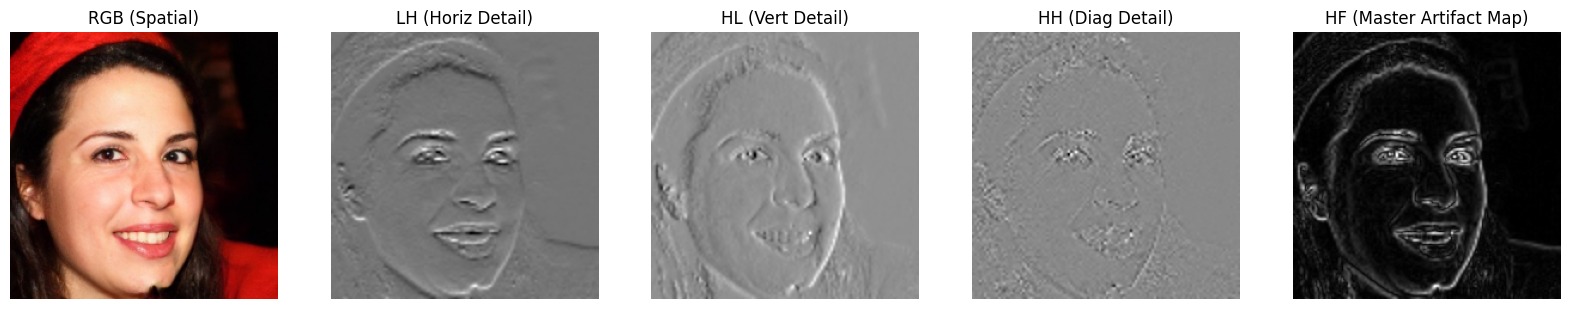

In [3]:
# Find a sample fake image from Pool A
sample_dir = os.path.join(POOL_A, "fake")
sample_img = os.path.join(sample_dir, os.listdir(sample_dir)[0])

hybrid_tensor = extract_hybrid_7ch(sample_img)

plt.figure(figsize=(20, 10))
titles = ["RGB (Spatial)", "LH (Horiz Detail)", "HL (Vert Detail)", "HH (Diag Detail)", "HF (Master Artifact Map)"]
images = [hybrid_tensor[:, :, :3], hybrid_tensor[:, :, 3], hybrid_tensor[:, :, 4], hybrid_tensor[:, :, 5], hybrid_tensor[:, :, 6]]

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray' if i > 0 else None)
    plt.title(titles[i])
    plt.axis('off')

print(f"Hybrid Tensor Shape: {hybrid_tensor.shape}")

## 3. High-Speed Training Generator (TensorFlow Dataset)

This uses python wrappers to make the DWT processing work with `tf.data` for fast training.

In [4]:
def hybrid_generator(directory, batch_size=16):
    classes = ['real', 'fake']
    img_paths = []
    labels = []
    
    for idx, cls in enumerate(classes):
        cls_dir = os.path.join(directory, cls)
        for img_name in os.listdir(cls_dir):
            img_paths.append(os.path.join(cls_dir, img_name))
            labels.append(idx)
            
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, labels))
    
    def process_wrapper(path_tensor, label):
        # Convert tensor string to python string
        path = path_tensor.numpy().decode('utf-8')
        features = extract_hybrid_7ch(path)
        if features is None: # Fallback for corrupted images
             features = np.zeros((IMG_SIZE, IMG_SIZE, 7))
        return features.astype(np.float32), np.array(label, dtype=np.float32)

    def py_func_wrapper(path, label):
        return tf.py_function(process_wrapper, [path, label], [tf.float32, tf.float32])
    
    # Standard Parallel Preprocessing Pipeline
    dataset = dataset.shuffle(len(img_paths))
    dataset = dataset.map(py_func_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return dataset, len(img_paths)

train_ds, train_count = hybrid_generator(POOL_A, batch_size=BATCH_SIZE)
print(f"\nGenerator Ready with {train_count} hybrid samples.")


Generator Ready with 40000 hybrid samples.
